# Customer Segmentation using K-Means Clustering

## Objective
Segment mall customers based on:
- Age
- Annual Income
- Spending Score

Goal:
Discover meaningful behavioral groups using unsupervised learning.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

sns.set(style="whitegrid")

In [2]:
df = pd.read_csv("../data/Mall_Customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


We drop:
- CustomerID (non-informative)
- Gender (not used in this segmentation)

Clustering will be based only on behavioral numeric features.

In [4]:
X = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]
X.head()

,Age,Annual Income (k$),Spending Score (1-100)
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40


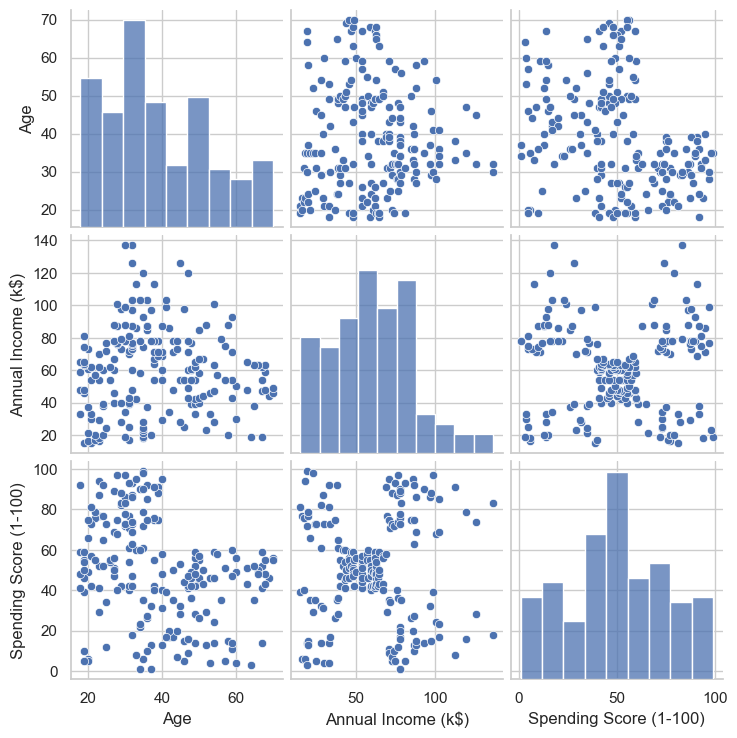

In [5]:
sns.pairplot(X)
plt.show()

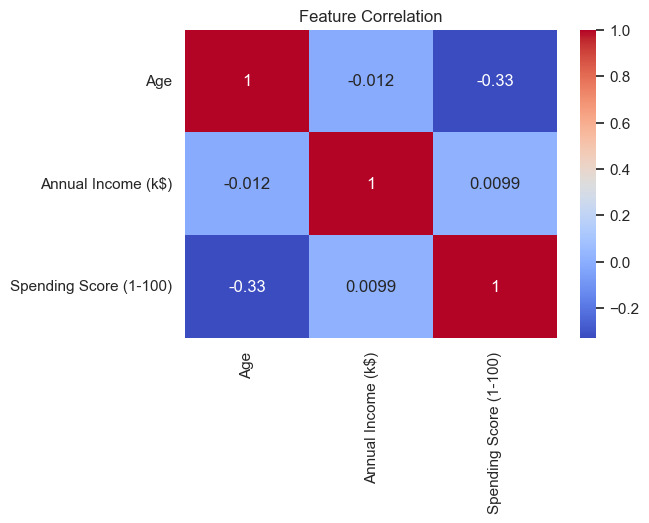

In [6]:
plt.figure(figsize=(6,4))
sns.heatmap(X.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation")
plt.show()

Observations:
- Weak correlation between income and spending.
- Moderate negative correlation between age and spending.
- Structure appears suitable for clustering.

In [7]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

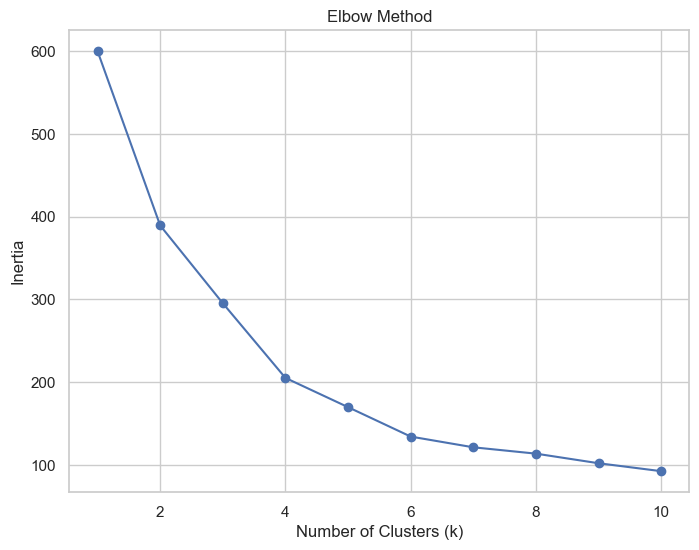

In [23]:
inertias = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8,6))
plt.plot(range(1,11), inertias, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.show()

In [9]:
for k in [3,4,5,6]:
    model = KMeans(n_clusters=k, random_state=42)
    labels = model.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f"k={k}, Silhouette Score={score:.3f}")

k=3, Silhouette Score=0.358
k=4, Silhouette Score=0.404
k=5, Silhouette Score=0.408
k=6, Silhouette Score=0.431


## Comparing k = 3, 4, 5, 6

Silhouette Scores:

- k=3 → 0.358
- k=4 → 0.404
- k=5 → 0.408
- k=6 → 0.431

Although k=6 gave the highest silhouette score, the improvement over k=4 was marginal. Since customer segmentation must remain interpretable and actionable, I selected k=4 as the final model.

In [10]:
kmeans = KMeans(n_clusters=4, random_state=42)
labels = kmeans.fit_predict(X_scaled)

df_clustered = df.copy()
df_clustered['Cluster'] = labels

In [11]:
df_clustered['Cluster'].value_counts()

Cluster
0    65
2    57
1    40
3    38
Name: count, dtype: int64

In [12]:
cluster_profiles = df_clustered.groupby('Cluster')[['Age',
                                                     'Annual Income (k$)',
                                                     'Spending Score (1-100)']].mean()

cluster_profiles

,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,53.984615,47.707692,39.969231
1,32.875000,86.100000,81.525000
2,25.438596,40.000000,60.298246
3,39.368421,86.500000,19.578947


In [13]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

centroids = kmeans.cluster_centers_
centroids_pca = pca.transform(centroids)

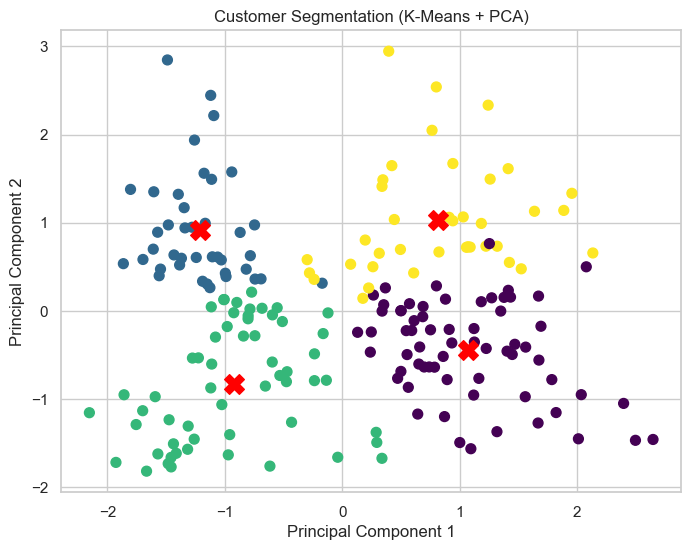

In [22]:
plt.figure(figsize=(8,6))

plt.scatter(X_pca[:,0], X_pca[:,1],
            c=labels,
            cmap='viridis',
            s=50)

plt.scatter(centroids_pca[:,0],
            centroids_pca[:,1],
            c='red',
            s=200,
            marker='X')

plt.title("Customer Segmentation (K-Means + PCA)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

Cluster Interpretation:

Cluster 0:
Older, moderate income, low spending.

Cluster 1:
Young, high income, high spending.
Premium segment.

Cluster 2:
Young, lower income, moderate spending.

Cluster 3:
Middle-aged, high income, low spending.
Untapped potential segment.

# Conclusion

K-Means clustering successfully identified four meaningful customer segments.

Elbow method suggested k=4 as optimal.
Silhouette score confirmed reasonable separation.

Using k=6 reduces inertia but does not improve interpretability.
Over-segmentation makes business insights weaker.

Therefore, k=4 is selected as the final model.